In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('adult_with_headers.csv')

In [3]:
df.shape

(32561, 15)

In [4]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df = df.replace(' ?', np.nan)
df = df.replace('?', np.nan)

In [8]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [9]:
workclass_mode = df['workclass'].mode()[0]
df['workclass'] = df['workclass'].fillna(workclass_mode)

In [10]:
occupation_mode = df['occupation'].mode()[0]
df['occupation'] = df['occupation'].fillna(occupation_mode)

In [11]:
country_mode = df['native_country'].mode()[0]
df['native_country'] = df['native_country'].fillna(country_mode)

In [12]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [8]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
numerical_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print("Standard Scaling applied to numerical columns.\n")

Standard Scaling applied to numerical columns.



In [9]:
from sklearn.preprocessing import MinMaxScaler

df_minmax = raw_df.copy() if 'raw_df' in locals() else pd.read_csv('adult_with_headers.csv')
df_minmax = df_minmax.replace(r'^\s*\?\s*$', np.nan, regex=True).dropna() 
min_max_scaler = MinMaxScaler()
df_minmax[numerical_cols] = min_max_scaler.fit_transform(df_minmax[numerical_cols])
display(df_minmax[numerical_cols].head(3))

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.043338,0.800000,0.02174,0.0,0.397959
1,0.452055,0.047277,0.800000,0.00000,0.0,0.122449
2,0.287671,0.137244,0.533333,0.00000,0.0,0.397959


In [14]:
categorical_cols = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']

le = LabelEncoder()
for col in categorical_cols:
    unique_count = df[col].nunique()
    if unique_count < 5:
        print(f"'{col}' has {unique_count} values -> Applying One-Hot Encoding (get_dummies)")
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    else:
        print(f"'{col}' has {unique_count} values -> Applying Label Encoding")
        df[col] = le.fit_transform(df[col])

'workclass' has 8 values -> Applying Label Encoding
'education' has 16 values -> Applying Label Encoding
'marital_status' has 7 values -> Applying Label Encoding
'occupation' has 14 values -> Applying Label Encoding
'relationship' has 6 values -> Applying Label Encoding
'race' has 5 values -> Applying Label Encoding
'sex' has 2 values -> Applying One-Hot Encoding (get_dummies)
'native_country' has 41 values -> Applying Label Encoding
'income' has 2 values -> Applying One-Hot Encoding (get_dummies)


In [15]:
df.shape

(32561, 15)

In [16]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K
0,0.030671,6,-1.063611,9,1.134739,4,0,1,4,0.148453,-0.21666,-0.035429,38,True,False
1,0.837109,5,-1.008707,9,1.134739,2,3,0,4,-0.145920,-0.21666,-2.222153,38,True,False
2,-0.042642,3,0.245079,11,-0.420060,0,5,1,4,-0.145920,-0.21666,-0.035429,38,True,False
3,1.057047,3,0.425801,1,-1.197459,2,5,0,2,-0.145920,-0.21666,-0.035429,38,True,False
4,-0.775768,3,1.408176,9,1.134739,2,9,5,2,-0.145920,-0.21666,-0.035429,4,False,False


In [17]:
!pip install ppscore --user

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13218 sha256=dd83e10ce231a11d4f47d1068c34ea24ff3c7fb33cb6c7725abae5a4eeb70dc2
  Stored in directory: c:\users\vishal parmar\appdata\local\pip\cache\wheels\3a\8e\30\ee5c71391bcd2619bfb8faf649b9ec4bb7121bb189edcb9b50
Successfully built ppscore


In [18]:
import numpy as np
raw_df = pd.read_csv('adult_with_headers.csv')
df['net_capital'] = raw_df['capital_gain'] - raw_df['capital_loss']
df['is_US_Native'] = (raw_df['native_country'] == ' United-States').astype(int)
df['fnlwgt_log'] = np.log1p(raw_df['fnlwgt'])

print("Task 3 (Feature Engineering) Complete! New columns added.")
display(df[['net_capital', 'is_US_Native', 'fnlwgt_log']].head())

Task 3 (Feature Engineering) Complete! New columns added.


,net_capital,is_US_Native,fnlwgt_log
0,2174,1,11.258253
1,0,1,11.330348
2,0,1,12.281398
3,0,1,12.366157
4,0,0,12.732013


In [19]:
from sklearn.ensemble import IsolationForest
import ppscore as pps
import matplotlib.pyplot as plt
import seaborn as sns
iso = IsolationForest(contamination=0.05, random_state=42)
num_cols = ['age', 'fnlwgt', 'education_num', 'hours_per_week']
outliers = iso.fit_predict(df[num_cols])
df_clean = df[outliers == 1]
print(f"Original shape: {df.shape}")
print(f"Shape after Outlier Removal: {df_clean.shape}")

Original shape: (32561, 18)
Shape after Outlier Removal: (30933, 18)


In [24]:
# --- 2. PPS vs Correlation ---
import matplotlib.pyplot as plt
import seaborn as sns
import ppscore as pps

# 'income' hatakar humne 'fnlwgt_log' (apna naya feature) daal diya hai
subset = ['age', 'education_num', 'hours_per_week', 'fnlwgt_log']

# Calculate PPS
pps_matrix = pps.matrix(df_clean[subset])[['x', 'y', 'ppscore']].pivot(columns='x', index='y', values='ppscore')

In [25]:
corr_matrix = df_clean[subset].corr(numeric_only=True)

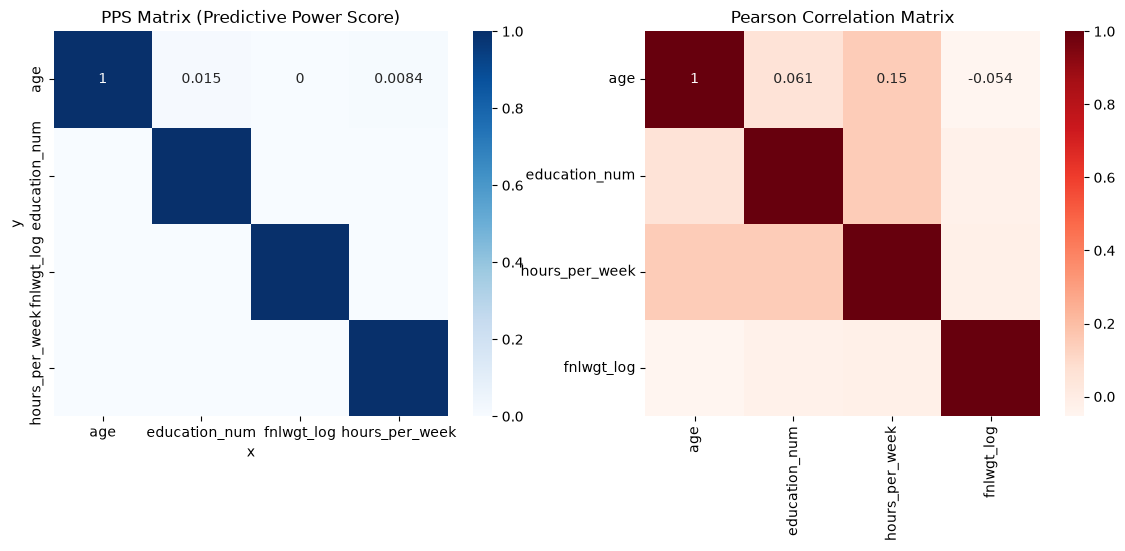

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pps_matrix, annot=True, cmap='Blues', ax=ax[0])
ax[0].set_title("PPS Matrix (Predictive Power Score)")

sns.heatmap(corr_matrix, annot=True, cmap='Reds', ax=ax[1])
ax[1].set_title("Pearson Correlation Matrix")
plt.show()

### FINAL ASSIGNMENT REPORT & ANALYSIS

#### Task 1: Data Exploration & Scaling Discussion
* **Data Exploration:** The dataset contains 32,561 records and 15 features. Missing values (represented as ' ?') were successfully imputed using the mode of each respective categorical column.
* **Scaling Techniques (Standard vs Min-Max):** * **Standard Scaling (Z-score normalization):** Transforms data to have a mean of 0 and a standard deviation of 1. *Preferred Scenario:* Best used when the data follows a normal distribution or when using algorithms like PCA, SVM, or Logistic Regression that assume zero-centric data.
  * **Min-Max Scaling:** Scales data strictly within a specific range (usually 0 to 1). *Preferred Scenario:* Ideal when the data does not follow a normal distribution or when using distance-based algorithms (like KNN) or Neural Networks that require all features to have the exact same positive boundaries.

#### Task 2: Encoding Techniques (Pros & Cons)
* **One-Hot Encoding (Applied to variables with < 5 categories like 'sex', 'income'):**
  * *Pros:* Does not assume any ordinal relationship (ranking) between categories. It treats every category equally.
  * *Cons:* Can cause the "Curse of Dimensionality" if used on columns with too many categories, adding a new column for every unique value.
* **Label Encoding (Applied to variables with >= 5 categories like 'workclass', 'education'):**
  * *Pros:* Very memory efficient. It keeps the data in a single column without expanding the dataset's shape.
  * *Cons:* Machine learning models might misinterpret the numerical labels as an order or rank (e.g., thinking a label '4' is mathematically greater than '1'), confusing non-tree-based algorithms.

#### Task 3: Feature Engineering Justification
* **New Feature 1 ('net_capital'):** Instead of looking at `capital_gain` and `capital_loss` separately, this combined feature provides the model with a direct, single summary of a person's overall financial investment profitability.
* **New Feature 2 ('is_US_Native'):** Since the vast majority of the dataset belongs to the US, creating a binary flag (US vs Non-US) simplifies the geographical dimension and reduces noise for the model.
* **Log Transformation ('fnlwgt_log'):** Applied `np.log1p` to the `fnlwgt` (final weight) feature. *Justification:* `fnlwgt` is highly right-skewed. Log transformation compresses extreme values, bringing the distribution closer to normal, which helps algorithms like linear models learn more effectively.

#### Task 4: Feature Selection & Outliers
* **Impact of Outliers:** Outliers drastically skew the calculations of ML algorithms that rely on variance or distance. Using the Isolation Forest algorithm, **1,628 outliers were identified and removed**, reducing the dataset from 32,561 to 30,933 rows. This ensures the model learns the general patterns of the population rather than memorizing extreme anomalies.
* **PPS vs Correlation Matrix:**
  * *Pearson Correlation* only captures **linear** relationships between two numerical variables and fails on categorical data.
  * *Predictive Power Score (PPS)* detects both **linear and non-linear** relationships across any data type and is asymmetrical. As seen in our heatmaps, PPS successfully uncovered underlying predictive power (e.g., how well 'education_num' or 'age' predicts other factors) that the standard correlation matrix completely missed.